### Analyses of Pairwise Comparison for classification
- Read F1 scores
- Read inference files for in-depth analyses

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix
from IPython.display import Markdown, display
import numpy as np

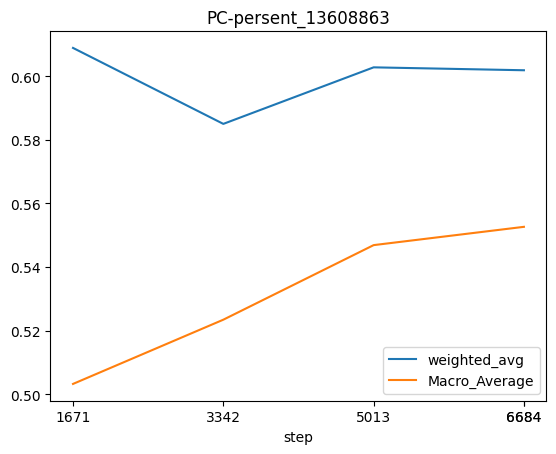

In [2]:
ts_filter = "202510161356"
slurm_filter = "13422137" # PerSent PC-persent_gemma2-9b_ep4-eval400

with open("pc_f1_scores.txt", "r") as f:
    all_results = [json.loads(line.strip()) for line in f if line.strip()]

# f1_data = [record for record in all_results if record.get("slurm_id") == slurm_filter]    
f1_data = [record for record in all_results if record.get("timestamp") == ts_filter]
f1_df = pd.DataFrame.from_records(f1_data)
f1_df['Macro_Average'] = f1_df[['Positive', 'Neutral', 'Negative']].mean(axis=1)
# f1_df['epoch'] = f1_df['experiment'].str.extract(r'epoch_(\d+)$').astype(int)
ax = f1_df[["weighted_avg", "Macro_Average", "step"]].plot.line(x='step')
ax.set_xticks(f1_df['step'])
ax.set_title(f1_df["experiment"].iloc[0].split("_")[0]+"_"+f1_df["slurm_id"].iloc[0])
plt.show()

In [3]:
# print(f1_df.sort_values("step").tail(1).to_markdown())
f1_df

,Negative,Neutral,Positive,weighted_avg,experiment,timestamp,seconds_since_trainstart,trainingtime,seconds_epochs_total,seconds_epochs_mean,step,total_steps,max_cuda_gb,slurm_id,Macro_Average
0,0.243902,0.534562,0.731250,0.608844,PC-persent_gemma2-9b_ep4_epoch_1_step1671,202510161356,23354,23354,22243.121878,22243.121878,1671,6684,48.980015,13608863,0.503238
1,0.408163,0.441417,0.720695,0.584967,PC-persent_gemma2-9b_ep4_epoch_2_step3342,202510161356,47268,46555,44332.172793,22166.086396,3342,6684,48.980015,13608863,0.523425
2,0.448598,0.454545,0.737446,0.602741,PC-persent_gemma2-9b_ep4_epoch_3_step5013,202510161356,71196,69770,66435.812133,22145.270711,5013,6684,48.980015,13608863,0.546863
3,0.469565,0.461538,0.726736,0.601825,PC-persent_gemma2-9b_ep4_epoch_4_step6684,202510161356,95324,93186,88713.434907,22178.358727,6684,6684,48.980015,13608863,0.552613
4,0.469565,0.461538,0.726736,0.601825,PC-persent_gemma2-9b_ep4_epoch_4_step6684,202510161356,97179,94312,88713.434907,22178.358727,6684,6684,48.980015,13608863,0.552613


In [54]:
# Extract test results from the training step defined above as best
scripts = """run_scripts/PC-persent_gemma2-9b_ep4_ent2ent_s102.sh
run_scripts/PC-persent_gemma2-9b_ep4_ent2ent_s103.sh
run_scripts/PC-persent_gemma2-9b_ep4_ent2ent_s104.sh
run_scripts/PC-persent_gemma2-9b_ep4_s102.sh
run_scripts/PC-persent_gemma2-9b_ep4_s103.sh
run_scripts/PC-persent_gemma2-9b_ep4_s104.sh"""
scripts = [s.split("/")[-1][:-3] for s in scripts.split("\n")]
scripts

# Keep those belonging to the runs above
with open("pc_f1_scores.txt", "r") as f:
    all_results = [json.loads(line.strip()) for line in f if line.strip()]
records = [d for d in all_results if any([d["experiment"].startswith(s+"_epoch") for s in scripts ]) ]

# Choose the last
records = [r for r in records if "epoch_4_" in r["experiment"]]

print(len(records))
f1_df = pd.DataFrame.from_records(records)
f1_df["exp"] = f1_df["experiment"].apply(lambda x: x.split("_epoch_")[0])
records = []
for exp, group in f1_df.groupby("exp"):
    records.append(group.sort_values("trainingtime", ascending=False).head(1))
    # display(group)
f1_df = pd.concat(records, axis=0)
f1_df["macro_avg"] = f1_df[["Negative", "Neutral", "Positive"]].mean(axis=1)

# Create a more descriptive grouping column
f1_df["textversion"] = f1_df["exp"].apply(lambda x: "ent2ent" if "ent2ent" in x else "fulltext")

# Group and calculate statistics
grouped_stats = f1_df.groupby("textversion")[[ "macro_avg"]].agg(['mean', 'std'])
# Convert to percentage and format with std in parentheses
for index in grouped_stats.index:
    mean_pct = grouped_stats.loc[index, ('macro_avg', 'mean') ] * 100
    std_pct = grouped_stats.loc[index, ('macro_avg', 'std')] * 100
    print(f"{index} & {mean_pct:.2f} ({std_pct:.1f})")

gs = f1_df.groupby("textversion")[[ "seconds_since_trainstart"]].agg(['mean'])
gs["mean_sec"] = gs[("seconds_since_trainstart","mean")].apply(lambda x: int(x/60))

12
ent2ent & 52.80 (1.0)
fulltext & 52.85 (0.6)


In [56]:
gs["mean_sec"]

textversion
ent2ent     1550
fulltext    1644
Name: mean_sec, dtype: int64

## Old under here|

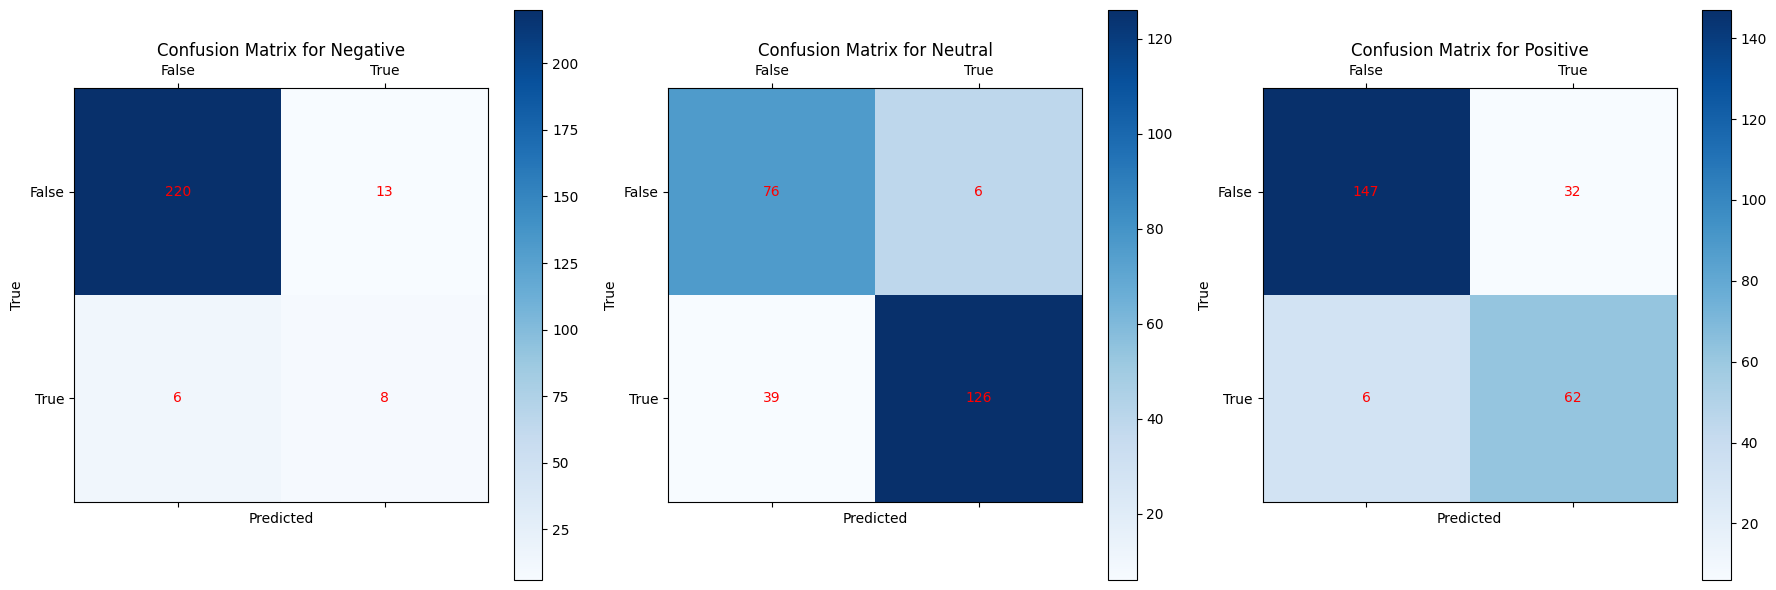

In [4]:
# Load JSON data from file
with open('inference/DEMO_1127_11_epoch_2.json', 'r', encoding='utf-8') as f:
    inference_data = pd.read_json(f)

# Create DataFrame with true and predicted labels
labels_df = pd.DataFrame({'true': inference_data['true_label'], 'pred': inference_data['pred_label']})

categories = ['Negative', 'Neutral', 'Positive']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, category in enumerate(categories):
    # Binarize labels for this category (one-vs-rest approach)
    y_true = labels_df['true'] == category
    y_pred = labels_df['pred'] == category

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    ax = axes[i]
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax, ax=ax)
    ax.set_title(f'Confusion Matrix for {category}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['False', 'True'])
    ax.set_yticklabels(['False', 'True'])

    # Annotate matrix with numbers
    for (x, y), val in np.ndenumerate(cm):
        ax.text(x, y, val, ha='center', va='center', color='red')

plt.tight_layout()
plt.show()

### Select from a span of timestamps

202509132121 27 gemma2-2b-norec_5000_4_1e4_epoch_0_step1350 



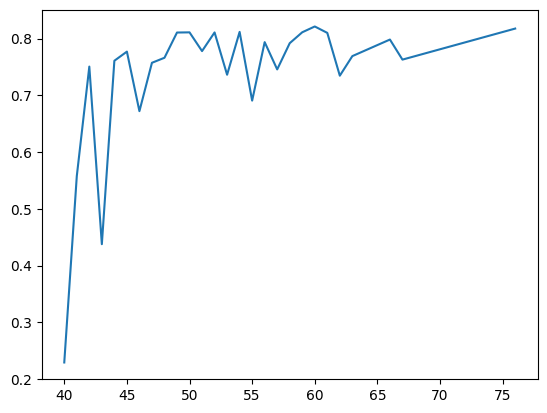

202509151503 2 gemma2-2b-hyperp_4_epoch_1_step86 



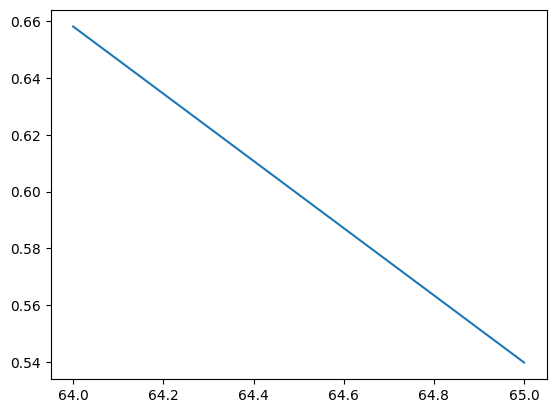

202509151931 11 gemma2-2b-hyperp_4_epoch_4_step512 



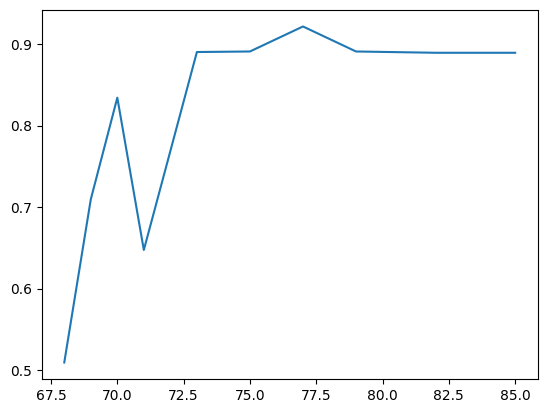

202509151941 55 gemma2-9b-persent_2_epoch_1_step3342 



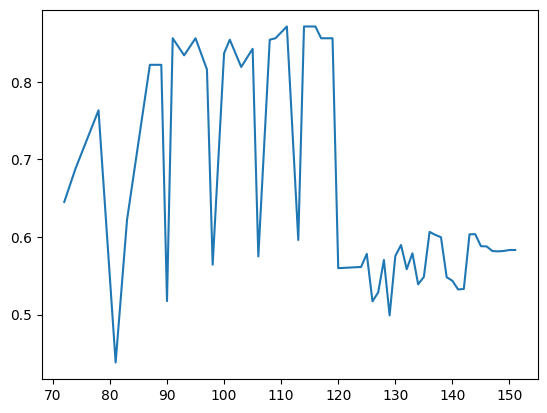

202509152007 17 gemma2-2b-persent_4_epoch_1_step1671 



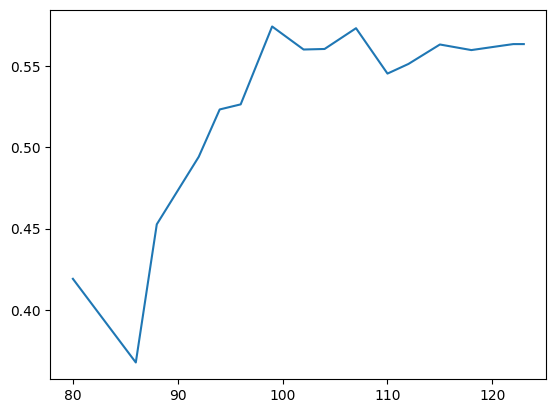

In [5]:

with open("f1_scores.txt", "r") as f:
    lines = f.readlines()
records = [json.loads(line) for line in lines]
df = pd.DataFrame.from_records(records)
df = df[df["experiment"].str.startswith("gemma")]
df.sort_values("experiment")
for timestamp, group in df.groupby("timestamp"):
    print(timestamp, len(group), group.tail(1)["experiment"].to_list()[0], "\n")
    ax = group["weighted_avg"].plot.line(x="step")
    # ax.set_xticks(group['step'])
    plt.show()

In [6]:
with open("sft_f1_scores.txt", "r") as f:
    lines = f.readlines()
records = [json.loads(line) for line in lines]
df = pd.DataFrame.from_records(records)
df = df[df['timestamp'] == "202509181559"]
df["train_step"] = df.train_step.apply(lambda x: x.split("-")[-1]) # like checkpoint-477
df["trainorder"] = df.train_step.apply(lambda x: int({"final":2999}.get(x,x)))
display()
df_sorted = df.sort_values("trainorder")
ax = df_sorted.plot.line(x="trainorder", y="weighted_avg", style='-o', figsize=(10, 6))
plt.show()
df_sorted


JSONDecodeError: Expecting value: line 2 column 1 (char 1)